In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from matplotlib import colors
from copy import deepcopy

from rashomon import hasse, counter

%matplotlib inline

## Setup: Load Data

In [2]:
# Define profiles and best profile
profiles, profiles_map = hasse.enumerate_profiles(4)
profile_cols = [str(x) for x in profiles]
best_profile = (1, 0, 1, 0)
best_profile_idx = profiles_map[best_profile]
true_best_profile = str(best_profile)

print(f"True best profile: {true_best_profile}")
print(f"Profile index: {best_profile_idx}")
print(f"Total profiles: {len(profile_cols)}")

True best profile: (1, 0, 1, 0)
Profile index: 10
Total profiles: 16


In [3]:
# File configuration
fname_prefix = "4arms_"
fname_suffix = "_30_100.csv"

rashomon_fname = f"../Results/4arms/{fname_prefix}rashomon{fname_suffix}"
blasso_fname = f"../Results/4arms/{fname_prefix}blasso_samples{fname_suffix}"
ssl_fname = f"../Results/4arms/{fname_prefix}ssl{fname_suffix}"
bootstrap_fname = f"../Results/4arms/{fname_prefix}bootstrap{fname_suffix}"
bootstrap_samples_fname = f"../Results/4arms/{fname_prefix}bootstrap_samples{fname_suffix}"
ppmx_fname = f"../Results/4arms/{fname_prefix}ppmx{fname_suffix}"

In [4]:
# Load Rashomon
rashomon_df = pd.read_csv(rashomon_fname).drop("Unnamed: 0", axis=1)
print(f"Rashomon: {len(rashomon_df)} models")

# Load Bayesian Lasso (samples)
blasso_df = pd.read_csv(blasso_fname).drop("Unnamed: 0", axis=1)
print(f"Bayesian Lasso: {len(blasso_df)} samples")

# Load Spike-Slab Lasso (samples)
ssl_df = pd.read_csv(ssl_fname).drop("Unnamed: 0", axis=1)
print(f"Spike-Slab Lasso: {len(ssl_df)} samples")

# Load Bootstrap (samples)
bootstrap_df = pd.read_csv(bootstrap_fname).drop("Unnamed: 0", axis=1)
bootstrap_samples_df = pd.read_csv(bootstrap_samples_fname).drop("Unnamed: 0", axis=1)
print(f"Bootstrap: {len(bootstrap_df)} summary, {len(bootstrap_samples_df)} samples")

# Load PPMx (samples)
ppmx_df = pd.read_csv(ppmx_fname)
if "Unnamed: 0" in ppmx_df.columns:
    ppmx_df = ppmx_df.drop("Unnamed: 0", axis=1)
print(f"PPMx: {len(ppmx_df)} samples")

Rashomon: 203940 models
Bayesian Lasso: 450000 samples
Spike-Slab Lasso: 440000 samples
Bootstrap: 100 summary, 100000 samples
PPMx: 100000 samples


In [5]:
def compute_prob(df, neg_log_posterior_col='neg_log_posterior'):
    """
    Compute binary presence in HPD region.
    Returns: fraction of simulations where profile appears at least once in HPD.
    """
    df_copy = df.copy()
    
    # Convert to log posterior and normalize
    df_copy['log_posterior'] = -df_copy[neg_log_posterior_col]
    df_copy['log_posterior_normalized'] = df_copy.groupby(['n_per_pol', 'sim_num'])['log_posterior'].transform(
        lambda x: x - x.max()
    )
    
    # Compute posterior weights
    df_copy['posterior_weight'] = np.exp(df_copy['log_posterior_normalized'])
    df_copy['posterior_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].transform(
        lambda x: x / x.sum()
    )
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', 'posterior_weight'], ascending=[True, True, False])

    return df_copy

In [6]:
# Compute posterior for Rashomon
lambda_rashomon = 1e-1
rashomon_df['neg_log_posterior'] = rashomon_df['MSE'] + lambda_rashomon * rashomon_df['num_pools']
rashomon_df = compute_prob(rashomon_df)

# Compute posterior for other methods
blasso_df = compute_prob(blasso_df)
ssl_df = compute_prob(ssl_df)
bootstrap_samples_df = compute_prob(bootstrap_samples_df, neg_log_posterior_col='penalized_loss')

ppmx_df["neg_log_posterior"] = -ppmx_df["neg_log_posterior"]
ppmx_df = compute_prob(ppmx_df)

## 1. HPD-Based Analysis (Fair Comparison to Rashomon)

For a fair comparison:
- **Rashomon**: Models within ε% of optimal (near-MAP region)
- **Bayesian methods**: Highest Posterior Density (HPD) region (e.g., 95% credible set)
- **Bootstrap**: Top models by penalized loss

This compares "high-quality model sets" across all methods.

In [52]:
def compute_frequency_inclusion(df, profile_col, group_cols=['n_per_pol', 'sim_num']):
    """
    Compute frequency-based inclusion rate.
    Returns: fraction of samples in each simulation that have the true best profile.
    """
    df_copy = df.copy()
    df_copy['has_best_profile'] = (df_copy[profile_col] > 0).astype(int)
    
    # Fraction per simulation
    freq_per_sim = df_copy.groupby(group_cols)['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'frequency_inclusion'}, inplace=True)
    
    # Overall mean
    overall_freq = freq_per_sim['frequency_inclusion'].mean()
    
    return freq_per_sim, overall_freq

# def compute_hpd_frequency(df, profile_col, credible_mass=0.95, neg_log_posterior_col='neg_log_posterior'):
#     """
#     Compute frequency in Highest Posterior Density (HPD) region.
    
#     Args:
#         df: DataFrame with samples
#         profile_col: Column name for the profile to check
#         credible_mass: Fraction of posterior mass to include (default 0.95)
#         neg_log_posterior_col: Column with negative log posterior values
    
#     Returns:
#         freq_per_sim: DataFrame with HPD frequency per simulation
#         overall_freq: Mean HPD frequency across simulations
#         hpd_size_per_sim: DataFrame with number of samples in HPD per simulation
#     """
#     df_copy = df.copy()
    
#     # # Convert to log posterior and normalize
#     # df_copy['log_posterior'] = -df_copy[neg_log_posterior_col]
#     # df_copy['log_posterior_normalized'] = df_copy.groupby(['n_per_pol', 'sim_num'])['log_posterior'].transform(
#     #     lambda x: x - x.max()
#     # )
    
#     # # Compute posterior weights
#     # df_copy['posterior_weight'] = np.exp(df_copy['log_posterior_normalized'])
#     # df_copy['posterior_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].transform(
#     #     lambda x: x / x.sum()
#     # )
    
#     # Sort by weight within each simulation (descending)
#     df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', 'posterior_weight'], ascending=[True, True, False])
    
#     # Cumulative weight
#     df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].cumsum()
    
#     # Keep only samples in HPD region
#     hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()
    
#     # Frequency within HPD region
#     hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
#     freq_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
#     freq_per_sim.rename(columns={'has_best_profile': 'hpd_frequency'}, inplace=True)
    
#     # Count samples in HPD region per simulation
#     hpd_size_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='hpd_size')
    
#     overall_freq = freq_per_sim['hpd_frequency'].mean()
    
#     return freq_per_sim, overall_freq, hpd_size_per_sim

def compute_hpd_frequency(df, profile_col, credible_mass=0.95, neg_log_posterior_col='neg_log_posterior'):
    """
    Compute frequency in Highest Posterior Density (HPD) region.
    
    Args:
        df: DataFrame with samples
        profile_col: Column name for the profile to check
        credible_mass: Fraction of posterior mass to include (default 0.95)
        neg_log_posterior_col: Column with negative log posterior values
    
    Returns:
        freq_per_sim: DataFrame with HPD frequency per simulation
        overall_freq: Mean HPD frequency across simulations
        hpd_size_per_sim: DataFrame with number of samples in HPD per simulation
    """
    df_copy = df.copy()
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', 'posterior_weight'], ascending=[True, True, False])
    
    # Cumulative weight
    df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].cumsum()
    
    # Keep only samples in HPD region
    hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()
    
    # Frequency within HPD region
    hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
    freq_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'hpd_frequency'}, inplace=True)
    
    # Count samples in HPD region per simulation
    hpd_size_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='hpd_size')
    
    # Get all unique simulations from the original data
    all_sims = df_copy[['n_per_pol', 'sim_num']].drop_duplicates()
    
    # Merge to ensure all simulations are represented (missing ones get NaN, then filled with 0)
    freq_all_sims = all_sims.merge(freq_per_sim, on=['n_per_pol', 'sim_num'], how='left')
    freq_all_sims['hpd_frequency'] = freq_all_sims['hpd_frequency'].fillna(0)
    
    # Also merge for hpd_size (missing simulations have 0 samples in HPD)
    hpd_size_all_sims = all_sims.merge(hpd_size_per_sim, on=['n_per_pol', 'sim_num'], how='left')
    hpd_size_all_sims['hpd_size'] = hpd_size_all_sims['hpd_size'].fillna(0)
    
    overall_freq = freq_all_sims['hpd_frequency'].mean()
    
    return freq_all_sims, overall_freq, hpd_size_all_sims

def compute_top_k_frequency(df, profile_col, loss_col, k_fraction=0.95):
    """
    Compute frequency in top-K models by loss.
    For Bootstrap: use penalized loss to define "top models".
    
    Args:
        df: DataFrame with samples
        profile_col: Column name for the profile to check
        loss_col: Column with loss values (lower is better)
        k_fraction: Fraction of models to include (default 0.95)
    
    Returns:
        freq_per_sim: DataFrame with top-K frequency per simulation
        overall_freq: Mean top-K frequency across simulations
    """
    df_copy = df.copy()
    
    # Sort by loss within each simulation (ascending - lower loss is better)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', loss_col], ascending=[True, True, True])
    
    # Assign rank
    df_copy['rank'] = df_copy.groupby(['n_per_pol', 'sim_num']).cumcount()
    
    # Determine K for each simulation
    total_per_sim = df_copy.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='total')
    total_per_sim['k_threshold'] = (total_per_sim['total'] * k_fraction).astype(int)
    
    # Merge back
    df_copy = df_copy.merge(total_per_sim[['n_per_pol', 'sim_num', 'k_threshold']], on=['n_per_pol', 'sim_num'])
    
    # Keep only top-K
    top_k_samples = df_copy[df_copy['rank'] < df_copy['k_threshold']].copy()
    
    # Frequency within top-K
    top_k_samples['has_best_profile'] = (top_k_samples[profile_col] > 0).astype(int)
    freq_per_sim = top_k_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'topk_frequency'}, inplace=True)
    
    overall_freq = freq_per_sim['topk_frequency'].mean()
    
    return freq_per_sim, overall_freq

In [53]:
def compute_hpd_frequency2(df, profile_col, credible_mass=0.95, posterior_weight_col='posterior_weight'):
    """
    Compute frequency in Highest Posterior Density (HPD) region.
    
    Args:
        df: DataFrame with samples
        profile_col: Column name for the profile to check
        credible_mass: Fraction of posterior mass to include (default 0.95)
        neg_log_posterior_col: Column with negative log posterior values
    
    Returns:
        freq_per_sim: DataFrame with HPD frequency per simulation
        overall_freq: Mean HPD frequency across simulations
        hpd_size_per_sim: DataFrame with number of samples in HPD per simulation
    """
    df_copy = df.copy()
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', posterior_weight_col], ascending=[True, True, False])
    
    # Cumulative weight
    df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])[posterior_weight_col].cumsum()
    
    # Keep only samples in HPD region
    hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()

    # Count samples in HPD region per simulation
    hpd_size_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='hpd_size')

    # Frequency within HPD region
    hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
    freq_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].mean().reset_index()
    freq_per_sim.rename(columns={'has_best_profile': 'hpd_frequency'}, inplace=True)
    
    # Count samples in HPD region per simulation
    hpd_size_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='hpd_size')
    
    overall_freq = freq_per_sim['hpd_frequency'].mean()
    
    return freq_per_sim, overall_freq, hpd_size_per_sim, hpd_size_per_sim

a, b, c, d = compute_hpd_frequency2(ssl_df, profile_col=true_best_profile, credible_mass=0.8)
d

,n_per_pol,sim_num,hpd_size
0,30,98,1


In [54]:
# Compute HPD-based inclusion (fair comparison to Rashomon)
credible_mass = 0.95

print(f"Computing HPD regions with {credible_mass*100}% posterior mass...\n")

# Rashomon: Already an epsilon-ball (keep as-is)
# rashomon_freq, rashomon_freq_mean = compute_frequency_inclusion(
#     rashomon_df, true_best_profile
# )
rashomon_hpd_freq, rashomon_hpd_freq_mean, rashomon_hpd_size = compute_hpd_frequency(
    rashomon_df, true_best_profile, credible_mass=credible_mass
)

# Bayesian Lasso: 95% HPD region
blasso_hpd_freq, blasso_hpd_freq_mean, blasso_hpd_size = compute_hpd_frequency(
    blasso_df, true_best_profile, credible_mass=credible_mass
)

# SSL: 95% HPD region
ssl_hpd_freq, ssl_hpd_freq_mean, ssl_hpd_size = compute_hpd_frequency(
    ssl_df, true_best_profile, credible_mass=credible_mass
)

# PPMx: 95% HPD region
ppmx_hpd_freq, ppmx_hpd_freq_mean, ppmx_hpd_size = compute_hpd_frequency(
    ppmx_df, true_best_profile, credible_mass=credible_mass
)

# Bootstrap: Top 95% by penalized loss
bootstrap_topk_freq, bootstrap_topk_freq_mean = compute_top_k_frequency(
    bootstrap_samples_df, true_best_profile, 'penalized_loss', k_fraction=credible_mass
)

print("HPD/Top-K Inclusion Rates (Fair Comparison):")
print(f"  Rashomon (95% HPD):       {rashomon_hpd_freq_mean:.3f}")
print(f"  Bayesian Lasso (95% HPD): {blasso_hpd_freq_mean:.3f}")
print(f"  SSL (95% HPD):            {ssl_hpd_freq_mean:.3f}")
print(f"  PPMx (95% HPD):           {ppmx_hpd_freq_mean:.3f}")
print(f"  Bootstrap (top 95%):      {bootstrap_topk_freq_mean:.3f}")

print(f"\nMean HPD/Top-K region sizes:")
print(f"  Rashomon:       {rashomon_hpd_size['hpd_size'].mean():.1f} samples")
print(f"  Bayesian Lasso: {blasso_hpd_size['hpd_size'].mean():.1f} samples")
print(f"  SSL:            {ssl_hpd_size['hpd_size'].mean():.1f} samples")
print(f"  PPMx:           {ppmx_hpd_size['hpd_size'].mean():.1f} samples")

Computing HPD regions with 95.0% posterior mass...

HPD/Top-K Inclusion Rates (Fair Comparison):
  Rashomon (95% HPD):       0.527
  Bayesian Lasso (95% HPD): 0.042
  SSL (95% HPD):            0.010
  PPMx (95% HPD):           0.090
  Bootstrap (top 95%):      0.468

Mean HPD/Top-K region sizes:
  Rashomon:       1936.1 samples
  Bayesian Lasso: 0.3 samples
  SSL:            0.0 samples
  PPMx:           0.1 samples


## 2. Binary Presence Analysis (At Least One)

Check if the true best profile appears **at least once** in each region/set (binary: yes/no).

In [55]:
def compute_binary_presence(df, profile_col, group_cols=['n_per_pol', 'sim_num']):
    """
    Compute binary presence: does the true best profile appear at least once?
    Returns: fraction of simulations where profile appears at least once (0 or 1 per simulation).
    """
    df_copy = df.copy()
    df_copy['has_best_profile'] = (df_copy[profile_col] > 0).astype(int)
    
    # Check if ANY sample in each simulation has the profile
    presence_per_sim = df_copy.groupby(group_cols)['has_best_profile'].max().reset_index()
    presence_per_sim.rename(columns={'has_best_profile': 'binary_presence'}, inplace=True)
    
    # Overall mean (fraction of simulations with at least one)
    overall_presence = presence_per_sim['binary_presence'].mean()
    
    return presence_per_sim, overall_presence

# def compute_hpd_binary_presence(df, profile_col, credible_mass=0.95, posterior_weight_col='posterior_weight'):
#     """
#     Compute binary presence in HPD region.
#     Returns: fraction of simulations where profile appears at least once in HPD.
#     """
#     df_copy = df.copy()
    
#     # Sort by weight within each simulation (descending)
#     df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', posterior_weight_col], ascending=[True, True, False])
    
#     # Cumulative weight
#     df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])[posterior_weight_col].cumsum()

#     # df_copy['has_best_profile'] = (df_copy[profile_col] > 0).astype(int)
#     # presence_per_sim = df_copy.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].max().reset_index()
#     # presence_per_sim.rename(columns={'has_best_profile': 'hpd_binary_presence'}, inplace=True)
#     # overall_presence = presence_per_sim['hpd_binary_presence'].mean()

#     # hpd_samples_presence = overall_presence[overall_presence['cumsum_weight'] <= credible_mass].copy()
    
#     # Keep only samples in HPD region
#     hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()
    
#     # Binary presence within HPD region
#     hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
#     presence_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].max().reset_index()
#     presence_per_sim.rename(columns={'has_best_profile': 'hpd_binary_presence'}, inplace=True)
    
#     overall_presence = presence_per_sim['hpd_binary_presence'].mean()
    
#     return presence_per_sim, overall_presence

def compute_hpd_binary_presence(df, profile_col, credible_mass=0.95, posterior_weight_col='posterior_weight'):
    """
    Compute binary presence in HPD region.
    Returns: fraction of simulations where profile appears at least once in HPD.
    """
    df_copy = df.copy()
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', posterior_weight_col], ascending=[True, True, False])
    
    # Cumulative weight
    df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])[posterior_weight_col].cumsum()
    
    # Keep only samples in HPD region
    hpd_samples = df_copy[df_copy['cumsum_weight'] <= credible_mass].copy()
    
    # Binary presence within HPD region
    hpd_samples['has_best_profile'] = (hpd_samples[profile_col] > 0).astype(int)
    presence_per_sim = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].max().reset_index()
    presence_per_sim.rename(columns={'has_best_profile': 'hpd_binary_presence'}, inplace=True)
    
    # Get all unique simulations from the original data
    all_sims = df_copy[['n_per_pol', 'sim_num']].drop_duplicates()
    
    # Merge to ensure all simulations are represented (missing ones get NaN, then filled with 0)
    presence_all_sims = all_sims.merge(presence_per_sim, on=['n_per_pol', 'sim_num'], how='left')
    presence_all_sims['hpd_binary_presence'] = presence_all_sims['hpd_binary_presence'].fillna(0)
    
    overall_presence = presence_all_sims['hpd_binary_presence'].mean()
    
    return presence_all_sims, overall_presence

def compute_top_k_binary_presence(df, profile_col, loss_col, k_fraction=0.95):
    """
    Compute binary presence in top-K models.
    Returns: fraction of simulations where profile appears at least once in top-K.
    """
    df_copy = df.copy()
    
    # Sort by loss within each simulation (ascending - lower loss is better)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', loss_col], ascending=[True, True, True])
    
    # Assign rank
    df_copy['rank'] = df_copy.groupby(['n_per_pol', 'sim_num']).cumcount()
    
    # Determine K for each simulation
    total_per_sim = df_copy.groupby(['n_per_pol', 'sim_num']).size().reset_index(name='total')
    total_per_sim['k_threshold'] = (total_per_sim['total'] * k_fraction).astype(int)
    
    # Merge back
    df_copy = df_copy.merge(total_per_sim[['n_per_pol', 'sim_num', 'k_threshold']], on=['n_per_pol', 'sim_num'])
    
    # Keep only top-K
    top_k_samples = df_copy[df_copy['rank'] < df_copy['k_threshold']].copy()
    
    # Binary presence within top-K
    top_k_samples['has_best_profile'] = (top_k_samples[profile_col] > 0).astype(int)
    presence_per_sim = top_k_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].max().reset_index()
    presence_per_sim.rename(columns={'has_best_profile': 'topk_binary_presence'}, inplace=True)
    
    overall_presence = presence_per_sim['topk_binary_presence'].mean()
    
    return presence_per_sim, overall_presence

In [56]:
# Compute binary presence for all methods

credible_mass = 0.8
credible_mass_str = f"{int(credible_mass*100)}%"

print("Computing binary presence (at least one occurrence)...\n")

# # Rashomon: ε-ball
# rashomon_presence, rashomon_presence_mean = compute_binary_presence(
#     rashomon_df, true_best_profile
# )

# Rashomon: 95% HPD region
rashomon_hpd_presence, rashomon_hpd_presence_mean = compute_hpd_binary_presence(
    rashomon_df, true_best_profile, credible_mass=credible_mass
)

# Rashomon: epsilon-ball (full posterior)
rashomon_full_presence, rashomon_full_presence_mean = compute_binary_presence(
    rashomon_df, true_best_profile
)

# Bayesian Lasso: 95% HPD region
blasso_hpd_presence, blasso_hpd_presence_mean = compute_hpd_binary_presence(
    blasso_df, true_best_profile, credible_mass=credible_mass
)

# Bayesian Lasso: Full posterior
blasso_full_presence, blasso_full_presence_mean = compute_binary_presence(
    blasso_df, true_best_profile
)

# SSL: 95% HPD region
ssl_hpd_presence, ssl_hpd_presence_mean = compute_hpd_binary_presence(
    ssl_df, true_best_profile, credible_mass=credible_mass
)

# SSL: Full posterior
ssl_full_presence, ssl_full_presence_mean = compute_binary_presence(
    ssl_df, true_best_profile
)

# PPMx: 95% HPD region
ppmx_hpd_presence, ppmx_hpd_presence_mean = compute_hpd_binary_presence(
    ppmx_df, true_best_profile, credible_mass=credible_mass
)

# PPMx: Full posterior
ppmx_full_presence, ppmx_full_presence_mean = compute_binary_presence(
    ppmx_df, true_best_profile
)

# Bootstrap: Top 95%
bootstrap_topk_presence, bootstrap_topk_presence_mean = compute_top_k_binary_presence(
    bootstrap_samples_df, true_best_profile, 'penalized_loss', k_fraction=credible_mass
)

# Bootstrap: All samples
bootstrap_full_presence, bootstrap_full_presence_mean = compute_binary_presence(
    bootstrap_samples_df, true_best_profile
)

print("Binary Presence - HPD/Top-K Region:")
print(f"  Rashomon ({credible_mass_str} HPD):       {rashomon_hpd_presence_mean:.3f} ({rashomon_hpd_presence_mean*100:.1f}% of simulations)")
print(f"  Bayesian Lasso ({credible_mass_str} HPD): {blasso_hpd_presence_mean:.3f} ({blasso_hpd_presence_mean*100:.1f}% of simulations)")
print(f"  SSL ({credible_mass_str} HPD):            {ssl_hpd_presence_mean:.3f} ({ssl_hpd_presence_mean*100:.1f}% of simulations)")
print(f"  PPMx ({credible_mass_str} HPD):           {ppmx_hpd_presence_mean:.3f} ({ppmx_hpd_presence_mean*100:.1f}% of simulations)")
print(f"  Bootstrap (top {credible_mass_str}):      {bootstrap_topk_presence_mean:.3f} ({bootstrap_topk_presence_mean*100:.1f}% of simulations)")

print("\nBinary Presence - Full Posterior/All Samples:")
print(f"  Rashomon (ε-ball):        {rashomon_full_presence_mean:.3f}")
print(f"  Bayesian Lasso (all):     {blasso_full_presence_mean:.3f}")
print(f"  SSL (all):                {ssl_full_presence_mean:.3f}")
print(f"  PPMx (all):               {ppmx_full_presence_mean:.3f}")
print(f"  Bootstrap (all):          {bootstrap_full_presence_mean:.3f}")

Computing binary presence (at least one occurrence)...

Binary Presence - HPD/Top-K Region:
  Rashomon (80% HPD):       1.000 (100.0% of simulations)
  Bayesian Lasso (80% HPD): 0.030 (3.0% of simulations)
  SSL (80% HPD):            0.010 (1.0% of simulations)
  PPMx (80% HPD):           0.050 (5.0% of simulations)
  Bootstrap (top 80%):      1.000 (100.0% of simulations)

Binary Presence - Full Posterior/All Samples:
  Rashomon (ε-ball):        1.000
  Bayesian Lasso (all):     1.000
  SSL (all):                1.000
  PPMx (all):               1.000
  Bootstrap (all):          1.000


In [57]:
# Compute full posterior frequency for MCMC methods

# Rashomon: all samples
rashomon_full_freq, rashomon_full_freq_mean = compute_frequency_inclusion(
    rashomon_df, true_best_profile
)

# Bayesian Lasso: all samples
blasso_full_freq, blasso_full_freq_mean = compute_frequency_inclusion(
    blasso_df, true_best_profile
)

# SSL: all samples
ssl_full_freq, ssl_full_freq_mean = compute_frequency_inclusion(
    ssl_df, true_best_profile
)

# PPMx: all samples
ppmx_full_freq, ppmx_full_freq_mean = compute_frequency_inclusion(
    ppmx_df, true_best_profile
)

# Bootstrap: all samples
bootstrap_full_freq, bootstrap_full_freq_mean = compute_frequency_inclusion(
    bootstrap_samples_df, true_best_profile
)

print("Full Posterior/Sample Frequency (Exploration Breadth):")
print(f"  Rashomon:        {rashomon_full_freq_mean:.3f}")
print(f"  Bayesian Lasso:  {blasso_full_freq_mean:.3f}")
print(f"  SSL:             {ssl_full_freq_mean:.3f}")
print(f"  PPMx:            {ppmx_full_freq_mean:.3f}")
print(f"  Bootstrap:       {bootstrap_full_freq_mean:.3f}")
print("\nNote: These are lower because they include low-probability regions.")

Full Posterior/Sample Frequency (Exploration Breadth):
  Rashomon:        0.527
  Bayesian Lasso:  0.157
  SSL:             0.103
  PPMx:            0.485
  Bootstrap:       0.477

Note: These are lower because they include low-probability regions.


## 4. Visualization: Four-Panel Comparison

In [58]:
# Combine all metrics for plotting
comparison_data = {
    'Method': ['Rashomon', 'Bayesian Lasso', 'SSL', 'PPMx', 'Bootstrap'],
    'HPD_Frequency': [rashomon_hpd_freq_mean, blasso_hpd_freq_mean, ssl_hpd_freq_mean, ppmx_hpd_freq_mean, bootstrap_topk_freq_mean],
    'Full_Frequency': [rashomon_full_freq_mean, blasso_full_freq_mean, ssl_full_freq_mean, ppmx_full_freq_mean, bootstrap_full_freq_mean],
    'HPD_Presence': [rashomon_hpd_presence_mean, blasso_hpd_presence_mean, ssl_hpd_presence_mean, ppmx_hpd_presence_mean, bootstrap_topk_presence_mean],
    'Full_Presence': [rashomon_full_presence_mean, blasso_full_presence_mean, ssl_full_presence_mean, ppmx_full_presence_mean, bootstrap_full_presence_mean],
}
comparison_df = pd.DataFrame(comparison_data)

comparison_df

,Method,HPD_Frequency,Full_Frequency,HPD_Presence,Full_Presence
0,Rashomon,0.527244,0.526798,1.00,1.0
1,Bayesian Lasso,0.041667,0.156956,0.03,1.0
2,SSL,0.010000,0.103009,0.01,1.0
3,PPMx,0.090000,0.484620,0.05,1.0
4,Bootstrap,0.468063,0.477200,1.00,1.0


/var/folders/ds/v36htzx10pv39ydvb7plxs1r0000gn/T/ipykernel_24117/705742875.py:66: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


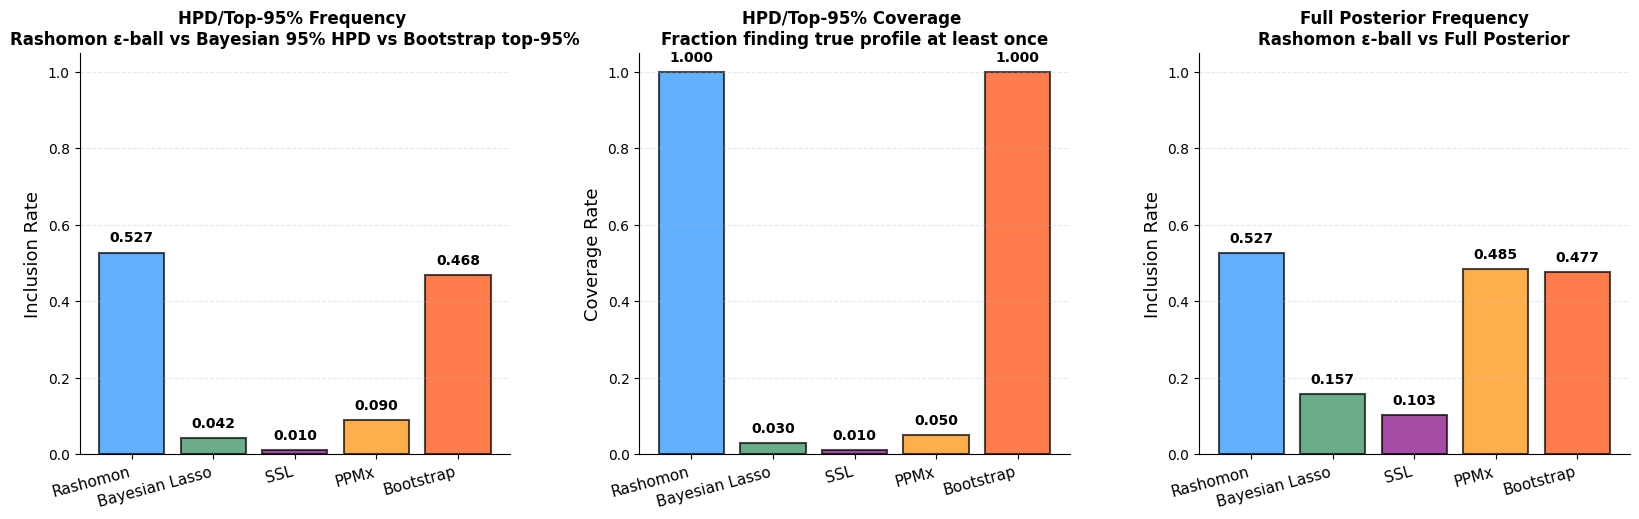

In [59]:
# Five-panel comparison plot
fig = plt.figure(figsize=(20, 12))
gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

colors_methods = ['dodgerblue', 'seagreen', 'purple', 'darkorange', 'orangered']
x_pos = np.arange(len(comparison_df))

# Panel 1: HPD/Top-K Frequency (FAIR COMPARISON)
ax1 = fig.add_subplot(gs[0, 0])
bars1 = ax1.bar(x_pos, comparison_df['HPD_Frequency'], color=colors_methods, alpha=0.7, edgecolor='black', linewidth=1.5)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(comparison_df['Method'], rotation=15, ha='right', fontsize=11)
ax1.set_ylabel('Inclusion Rate', fontsize=13)
ax1.set_title('HPD/Top-95% Frequency \nRashomon ε-ball vs Bayesian 95% HPD vs Bootstrap top-95%',
              fontsize=12, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.grid(axis='y', alpha=0.3, linestyle='--')
ax1.spines[['right', 'top']].set_visible(False)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    if not np.isnan(height):
        ax1.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 2: HPD/Top-K Binary Presence (COVERAGE)
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(x_pos, comparison_df['HPD_Presence'], color=colors_methods, alpha=0.7, edgecolor='black', linewidth=1.5)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(comparison_df['Method'], rotation=15, ha='right', fontsize=11)
ax2.set_ylabel('Coverage Rate', fontsize=13)
ax2.set_title('HPD/Top-95% Coverage \nFraction finding true profile at least once',
              fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1.05)
ax2.grid(axis='y', alpha=0.3, linestyle='--')
ax2.spines[['right', 'top']].set_visible(False)

# Add value labels
for bar in bars2:
    height = bar.get_height()
    if not np.isnan(height):
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Panel 4: Full Posterior/Sample Frequency (EXPLORATION BREADTH)
ax4 = fig.add_subplot(gs[0, 2])
bars4 = ax4.bar(x_pos, comparison_df['Full_Frequency'], color=colors_methods, alpha=0.7, edgecolor='black', linewidth=1.5)
ax4.set_xticks(x_pos)
ax4.set_xticklabels(comparison_df['Method'], rotation=15, ha='right', fontsize=11)
ax4.set_ylabel('Inclusion Rate', fontsize=13)
ax4.set_title('Full Posterior Frequency\nRashomon ε-ball vs Full Posterior',
              fontsize=12, fontweight='bold')
ax4.set_ylim(0, 1.05)
ax4.grid(axis='y', alpha=0.3, linestyle='--')
ax4.spines[['right', 'top']].set_visible(False)

# Add value labels
for bar in bars4:
    height = bar.get_height()
    if not np.isnan(height):
        ax4.text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{height:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')


plt.tight_layout()
# plt.savefig('../Figures/reff/posterior_comparison_five_panel.png', dpi=300, bbox_inches='tight')
plt.show()

## 5. Credible Interval Size Analysis

Analyze how different credible interval sizes (90%, 95%, 99%, etc.) affect:
1. Coverage: Fraction of simulations finding the true profile at least once
2. Sample size: Number of models/samples included in the region

In [ ]:
# # Compute coverage and sample size for different credible interval sizes
# credible_levels = list(np.arange(0.05, 1, 0.05)) + [0.99, 1]
# # credible_levels = [0.5, 0.9]

# # Store results
# results_by_level = {
#     'credible_level': [],
#     'rashomon_coverage': [],
#     'rashomon_mean_size': [],
#     'blasso_coverage': [],
#     'blasso_mean_size': [],
#     'ssl_coverage': [],
#     'ssl_mean_size': [],
#     'ppmx_coverage': [],
#     'ppmx_mean_size': [],
#     'bootstrap_coverage': [],
#     'bootstrap_mean_size': []
# }

# for level in credible_levels:
#     print(f"Computing for credible level {level:.0%}...")

#     # Rashomon
#     rashomon_presence_level, rashomon_coverage_level = compute_hpd_binary_presence(
#         rashomon_df, true_best_profile, credible_mass=level
#     )
#     _, rashomon_size_level, rashomon_freq = compute_hpd_frequency(
#         rashomon_df, true_best_profile, credible_mass=level
#     )

#     # Bayesian Lasso
#     blasso_presence_level, blasso_coverage_level = compute_hpd_binary_presence(
#         blasso_df, true_best_profile, credible_mass=level
#     )
#     _, blasso_size_level, blasso_freq = compute_hpd_frequency(
#         blasso_df, true_best_profile, credible_mass=level
#     )

#     # SSL
#     ssl_presence_level, ssl_coverage_level = compute_hpd_binary_presence(
#         ssl_df, true_best_profile, credible_mass=level
#     )
#     _, ssl_size_level, ssl_freq = compute_hpd_frequency(
#         ssl_df, true_best_profile, credible_mass=level
#     )

#     # PPMx
#     ppmx_presence_level, ppmx_coverage_level = compute_hpd_binary_presence(
#         ppmx_df, true_best_profile, credible_mass=level
#     )
#     _, ppmx_size_level, ppmx_freq = compute_hpd_frequency(
#         ppmx_df, true_best_profile, credible_mass=level
#     )

#     # Bootstrap
#     bootstrap_presence_level, bootstrap_coverage_level = compute_hpd_binary_presence(
#         bootstrap_samples_df, true_best_profile, credible_mass=level
#     )
#     _, bootstrap_size_level, bootstrap_freq = compute_hpd_frequency(
#         bootstrap_samples_df, true_best_profile, credible_mass=level
#     )

#     # Store results
#     results_by_level['credible_level'].append(level)
#     results_by_level['rashomon_coverage'].append(rashomon_coverage_level)
#     results_by_level['rashomon_mean_size'].append(rashomon_freq["hpd_size"].mean())
#     results_by_level['blasso_coverage'].append(blasso_coverage_level)
#     results_by_level['blasso_mean_size'].append(blasso_freq["hpd_size"].mean())
#     results_by_level['ssl_coverage'].append(ssl_coverage_level)
#     results_by_level['ssl_mean_size'].append(ssl_freq['hpd_size'].mean())
#     results_by_level['ppmx_coverage'].append(ppmx_coverage_level)
#     results_by_level['ppmx_mean_size'].append(ppmx_freq['hpd_size'].mean())
#     results_by_level['bootstrap_coverage'].append(bootstrap_coverage_level)
#     results_by_level['bootstrap_mean_size'].append(bootstrap_freq['hpd_size'].mean())

# # Convert to DataFrame
# credible_analysis_df = pd.DataFrame(results_by_level)
# print("\nDone!")
# # credible_analysis_df

Computing for credible level 5%...
Computing for credible level 10%...
Computing for credible level 15%...
Computing for credible level 20%...
Computing for credible level 25%...
Computing for credible level 30%...
Computing for credible level 35%...
Computing for credible level 40%...
Computing for credible level 45%...
Computing for credible level 50%...
Computing for credible level 55%...
Computing for credible level 60%...
Computing for credible level 65%...
Computing for credible level 70%...
Computing for credible level 75%...
Computing for credible level 80%...
Computing for credible level 85%...
Computing for credible level 90%...
Computing for credible level 95%...
Computing for credible level 99%...
Computing for credible level 100%...

Done!


In [ ]:
# Compute coverage and sample size for different credible interval sizes
credible_levels = list(np.arange(0.05, 1, 0.05)) + [0.99, 1.0]

print("Computing HPD regions for all credible levels at once...")

# For each method, compute cumulative weights and add credible level columns
methods = {
    'rashomon': rashomon_df,
    'blasso': blasso_df,
    'ssl': ssl_df,
    'ppmx': ppmx_df,
    'bootstrap': bootstrap_samples_df
}

results_dfs = {}

for method_name, df in methods.items():
    print(f"Processing {method_name}...")
    
    df_copy = df.copy()
    
    # Sort by weight within each simulation (descending)
    df_copy = df_copy.sort_values(['n_per_pol', 'sim_num', 'posterior_weight'], ascending=[True, True, False])
    
    # Cumulative weight
    df_copy['cumsum_weight'] = df_copy.groupby(['n_per_pol', 'sim_num'])['posterior_weight'].cumsum()
    
    # Add indicator for best profile
    df_copy['has_best_profile'] = (df_copy[true_best_profile] > 0).astype(int)
    
    # For each credible level, mark which samples are included
    for level in credible_levels:
        df_copy[f'in_hpd_{int(level*100)}'] = (df_copy['cumsum_weight'] <= level).astype(int)
    
    results_dfs[method_name] = df_copy

print("\nComputing metrics across all credible levels...")

# Now compute metrics for each credible level
results_by_level = {
    'credible_level': [],
    'rashomon_coverage': [],
    'rashomon_mean_size': [],
    'blasso_coverage': [],
    'blasso_mean_size': [],
    'ssl_coverage': [],
    'ssl_mean_size': [],
    'ppmx_coverage': [],
    'ppmx_mean_size': [],
    'bootstrap_coverage': [],
    'bootstrap_mean_size': []
}

# Get all unique simulations (for normalization)
all_sims = rashomon_df[['n_per_pol', 'sim_num']].drop_duplicates()
n_sims = len(all_sims)

for level in credible_levels:
    level_pct = int(level * 100)
    col_name = f'in_hpd_{level_pct}'
    
    results_by_level['credible_level'].append(level)
    
    for method_name in ['rashomon', 'blasso', 'ssl', 'ppmx', 'bootstrap']:
        df = results_dfs[method_name]
        
        # Filter to samples in HPD region for this level
        hpd_samples = df[df[col_name] == 1].copy()
        
        # Binary presence: does best profile appear at least once in HPD per simulation?
        if len(hpd_samples) > 0:
            presence = hpd_samples.groupby(['n_per_pol', 'sim_num'])['has_best_profile'].max()
            # Merge with all sims to ensure we count simulations with no HPD samples as 0
            presence_all = all_sims.merge(presence.reset_index(), on=['n_per_pol', 'sim_num'], how='left')
            coverage = presence_all['has_best_profile'].fillna(0).mean()
            
            # Mean size: average number of samples in HPD region per simulation
            hpd_sizes = hpd_samples.groupby(['n_per_pol', 'sim_num']).size()
            sizes_all = all_sims.merge(hpd_sizes.reset_index(name='hpd_size'), on=['n_per_pol', 'sim_num'], how='left')
            mean_size = sizes_all['hpd_size'].fillna(0).mean()
        else:
            coverage = 0.0
            mean_size = 0.0
        
        results_by_level[f'{method_name}_coverage'].append(coverage)
        results_by_level[f'{method_name}_mean_size'].append(mean_size)

# Convert to DataFrame
credible_analysis_df = pd.DataFrame(results_by_level)
print("\nDone!")


Computing metrics across all credible levels...


KeyError: 'in_hpd_5'

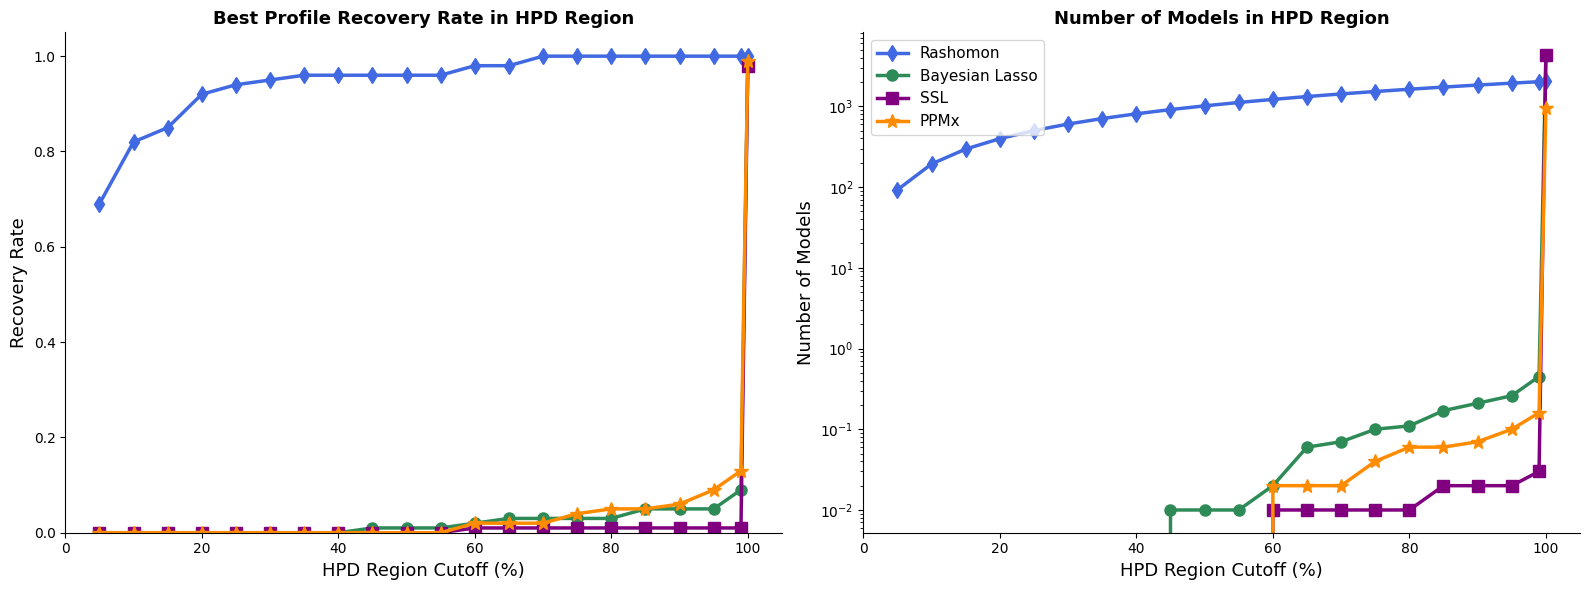

In [82]:
# Plot 1: Coverage vs Credible Level
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Coverage (fraction finding true profile at least once)
ax1 = axes[0]
ax1.plot(credible_analysis_df['credible_level'] * 100,
         credible_analysis_df['rashomon_coverage'],
         marker='d', markersize=8, linewidth=2.5, label='Rashomon', color='royalblue')
ax1.plot(credible_analysis_df['credible_level'] * 100,
         credible_analysis_df['blasso_coverage'],
         marker='o', markersize=8, linewidth=2.5, label='Bayesian Lasso', color='seagreen')
ax1.plot(credible_analysis_df['credible_level'] * 100,
         credible_analysis_df['ssl_coverage'],
         marker='s', markersize=8, linewidth=2.5, label='SSL', color='purple')
ax1.plot(credible_analysis_df['credible_level'] * 100,
         credible_analysis_df['ppmx_coverage'],
         marker='*', markersize=10, linewidth=2.5, label='PPMx', color='darkorange')
# ax1.plot(credible_analysis_df['credible_level'] * 100,
#          credible_analysis_df['bootstrap_coverage'],
#          marker='^', markersize=8, linewidth=2.5, label='Bootstrap', color='orangered')

ax1.set_xlabel('HPD Region Cutoff (%)', fontsize=13)
ax1.set_ylabel('Recovery Rate', fontsize=13)
ax1.set_title('Best Profile Recovery Rate in HPD Region',
              fontsize=13, fontweight='bold')
ax1.set_ylim(0, 1.05)
ax1.set_xlim(0, 105)
# ax1.legend(loc='upper left', fontsize=11)
# ax1.grid(alpha=0.3, linestyle='--')
ax1.spines[['right', 'top']].set_visible(False)

# Plot 2: Mean sample size vs Credible Level
ax2 = axes[1]
ax2.plot(credible_analysis_df['credible_level'] * 100,
         credible_analysis_df['rashomon_mean_size'],
         marker='d', markersize=8, linewidth=2.5, label='Rashomon', color='royalblue')
ax2.plot(credible_analysis_df['credible_level'] * 100,
         credible_analysis_df['blasso_mean_size'],
         marker='o', markersize=8, linewidth=2.5, label='Bayesian Lasso', color='seagreen')
ax2.plot(credible_analysis_df['credible_level'] * 100,
         credible_analysis_df['ssl_mean_size'],
         marker='s', markersize=8, linewidth=2.5, label='SSL', color='purple')
ax2.plot(credible_analysis_df['credible_level'] * 100,
         credible_analysis_df['ppmx_mean_size'],
         marker='*', markersize=10, linewidth=2.5, label='PPMx', color='darkorange')
# ax2.plot(credible_analysis_df['credible_level'] * 100,
#          credible_analysis_df['bootstrap_mean_size'],
#          marker='^', markersize=8, linewidth=2.5, label='Bootstrap', color='orangered')

# ax2.set_ylim(0, 2100)
ax2.set_yscale('log')
ax2.set_xlim(0, 105)
ax2.set_xlabel('HPD Region Cutoff (%)', fontsize=13)
ax2.set_ylabel('Number of Models', fontsize=13)
ax2.set_title('Number of Models in HPD Region',
              fontsize=13, fontweight='bold')
ax2.legend(loc='upper left', fontsize=11)
# ax2.grid(alpha=0.3, linestyle='--')
ax2.spines[['right', 'top']].set_visible(False)

plt.tight_layout()
# plt.savefig('../Figures/reff/credible_interval_analysis.png', dpi=300, bbox_inches='tight')
plt.show()